# 02. Demo Inference with LoFTR
This notebook demonstrates the basic inference pipeline using the pre-trained LoFTR (Local Feature TRansformer) model. 

We wrap the inference logic within our standardized `BaseMatcher` interface. The wrapper automatically handles tensor reshaping, normalization, and CLAHE (Contrast Limited Adaptive Histogram Equalization) application, which is crucial for highlighting structural features across different seasons.

✅ Знайдено 2 унікальних локацій із парами 'До/Після'.
🧠 Використовую БАЗОВІ ваги LoFTR (outdoor) для дебагу.


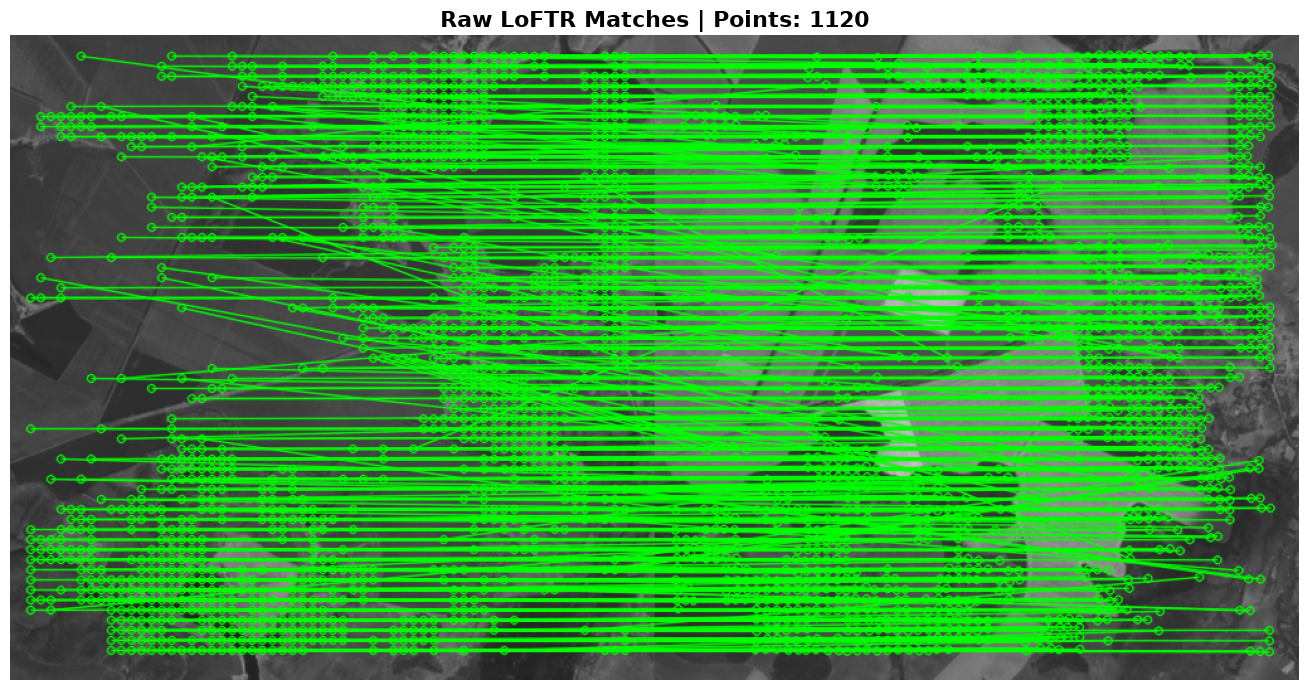

In [1]:
import os
import sys
import rasterio

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data.dataset import PairedDeforestationDataset
from src.data.roi import get_smart_roi_crops
from src.matching.loftr_matcher import LoftrMatcher
from src.visualization.visualizer import Visualizer

data_dir = os.path.expanduser(r"~\.cache\kagglehub\datasets\isaienkov\deforestation-in-ukraine\versions\1")
dataset = PairedDeforestationDataset(data_dir=data_dir)
pair = dataset.pairs[0]

with rasterio.open(pair["before_b04"]) as src_b:
    img_b_full = src_b.read(1)
with rasterio.open(pair["after_b04"]) as src_a:
    img_a_full = src_a.read(1)

x, y = get_smart_roi_crops(img_b_full, img_a_full, tile_size=512, num_crops=1)[0]
img_b = img_b_full[y:y+512, x:x+512]
img_a = img_a_full[y:y+512, x:x+512]

# Initialize LoFTR and match
matcher = LoftrMatcher(use_custom_weights=False)
mkpts0, mkpts1, mconf = matcher.match(img_b, img_a)

# Visualize all raw matches
visualizer = Visualizer()
visualizer.draw_matches(img_b, img_a, mkpts0, mkpts1, title=f"Raw LoFTR Matches | Points: {len(mkpts0)}")